**Figure 4: Embedding geometry detects splicing epistasis across three independent systems.** **(a)** FAS exon 6 saturation mutagenesis (16,728 variant pairs): partial Spearman correlation between model-derived epistasis metrics and experimentally measured epistasis magnitude (|empirical epistasis|), controlling for genomic distance. Each bar shows the best-performing metric per model: raw normalized epistasis $R_\text{singles}$ (blue) or Mahalanobis-calibrated distance (terracotta). AlphaGenome achieves the highest correlation (ρ = 0.068, p = 2.1 × 10⁻¹⁸) using Mahalanobis calibration, while Borzoi improves from non-significant (ρ = 0.007) to ρ = 0.052 after calibration. **(b)** MST1R exon 11 minigene assay (966 variant pairs): Spearman correlation between model epistasis and allele-exchange exon skipping percentage. Borzoi leads (ρ = 0.096, p = 0.003). Gray bars indicate non-significant correlations. **(c)** KRAS compensatory epistasis: magnitude ratio distributions (violins) for all 13,455 SNV×SNV pairs within ±150 bp of the G60G–Q61K locus, with the known compensatory pair marked (red dots). Percentile annotations show where the target pair ranks within the background. AlphaGenome places it at the 0.04th percentile (MR = 0.069), indicating strong corrective epistasis consistent with the known biology of splice-site suppression.

**Supplementary panels** (below): KRAS single-mutation WT distance analysis showing how each model perceives the G60G synonymous mutation (red) vs Q61K missense (gold) relative to all other single mutations in the neighborhood.

In [ ]:
import warnings, sys
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

# ── Configuration via paper_data_config ──
sys.path.insert(0, str(Path("..").resolve()))
from paper_data_config import EPISTASIS_PAPER_ROOT

PARQUET_DIR = EPISTASIS_PAPER_ROOT / 'combined_parquets' / 'parquets_epi'
PAIRS_TSV = EPISTASIS_PAPER_ROOT / 'data' / 'all_pairs_combined.tsv'
OUT_DIR = EPISTASIS_PAPER_ROOT / 'figures'
import os; os.makedirs(OUT_DIR, exist_ok=True)

# ── Nature style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 7, 'axes.linewidth': 0.4, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6.5,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'xtick.major.width': 0.4, 'ytick.major.width': 0.4,
    'xtick.major.pad': 2, 'ytick.major.pad': 2,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.unicode_minus': False,
})

GRAY_LIGHT, GRAY_MID, GRAY_DARK = '#E8E8E8', '#999999', '#333333'
mm = 1 / 25.4

MODEL_DISPLAY = {
    'alphagenome': 'AlphaGenome', 'borzoi': 'Borzoi', 'caduceus': 'Caduceus',
    'convnova': 'ConvNova', 'dnabert': 'DNABERT', 'evo2': 'Evo2',
    'hyenadna': 'HyenaDNA', 'mutbert': 'MutBERT',
    'nt50_3mer': 'NT-50M-3mer', 'nt50_multi': 'NT-50M',
    'nt100_multi': 'NT-100M', 'nt250_multi': 'NT-250M',
    'nt500_multi': 'NT-500M', 'nt500_ref': 'NT-500M-ref',
    'nt2500_multi': 'NT-2.5B', 'nt2500_okgp': 'NT-2.5B-1kGP',
    'rinalmo': 'RiNALMo', 'specieslm': 'SpeciesLM', 'spliceai': 'SpliceAI',
}

def style_ax(ax):
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_linewidth(0.4)
        ax.spines[sp].set_color(GRAY_MID)
    ax.tick_params(colors=GRAY_DARK)
    ax.xaxis.grid(True, color=GRAY_LIGHT, lw=0.3, zorder=0)
    ax.set_axisbelow(True)

print('Imports OK')

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════════════

SOURCES = ['fas_exon', 'kras_neighborhood', 'mst1r_splicing']

model_keys = sorted([f.stem.replace('epistasis_metrics_', '').replace('_combined', '')
                      for f in PARQUET_DIR.glob('*.parquet')])

print(f'Loading {len(model_keys)} models (3 sources only)...')
model_data = {}
for mk in model_keys:
    fp = PARQUET_DIR / f'epistasis_metrics_{mk}_combined.parquet'
    df = pd.read_parquet(fp)
    df = df[df['source'].isin(SOURCES)].drop_duplicates(
        subset=['source', 'epistasis_id'], keep='first').reset_index(drop=True)
    model_data[mk] = df
    print(f'  {mk}: {len(df):,} rows')

# Empirical data
print('\nLoading empirical pairs...')
pairs_tsv = pd.read_csv(PAIRS_TSV, sep='\t', low_memory=False)

fas_emp = pairs_tsv[pairs_tsv['source'] == 'fas_exon'][
    ['epistasis_id', 'empirical_epistasis', 'distance_bp']
].dropna(subset=['empirical_epistasis']).copy()
fas_emp['distance'] = fas_emp['distance_bp'].astype(float)
fas_emp['emp_abs'] = fas_emp['empirical_epistasis'].abs()

mst_emp = pairs_tsv[pairs_tsv['source'] == 'mst1r_splicing'][
    ['epistasis_id', 'ae_skipping_pct', 'distance_bp']
].dropna(subset=['ae_skipping_pct']).copy()
mst_emp['distance'] = mst_emp['distance_bp'].astype(float)

print(f'  FAS: {len(fas_emp)} pairs')
print(f'  MST1R: {len(mst_emp)} pairs')
print('Done.')

Loading 19 models (3 sources only)...
  alphagenome: 31,154 rows
  borzoi: 31,154 rows
  caduceus: 31,154 rows
  convnova: 31,154 rows
  dnabert: 31,154 rows
  evo2: 30,183 rows
  hyenadna: 31,154 rows
  mutbert: 31,154 rows
  nt100_multi: 31,154 rows
  nt2500_multi: 31,154 rows
  nt2500_okgp: 31,154 rows
  nt250_multi: 31,154 rows
  nt500_multi: 31,154 rows
  nt500_ref: 31,154 rows
  nt50_3mer: 31,154 rows
  nt50_multi: 31,154 rows
  rinalmo: 31,154 rows
  specieslm: 31,154 rows
  spliceai: 16,728 rows

Loading empirical pairs...
  FAS: 16728 pairs
  MST1R: 966 pairs
Done.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════════

def parse_distance(eid):
    parts = eid.split('|')
    return abs(int(parts[1].split(':')[2]) - int(parts[0].split(':')[2]))

print('Helpers defined.')

Helpers defined.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# PANEL A: FAS partial Spearman rho (Euclidean + Mahalanobis)
# ═══════════════════════════════════════════════════════════════════════

FAS_METRICS = ['epi_R_singles', 'global_epi_mahal']
fas_rows = []

for mk in tqdm(model_data.keys(), desc='FAS partial corr'):
    df_model = model_data[mk]
    fas_df = df_model[df_model['source'] == 'fas_exon'].copy()
    if len(fas_df) == 0:
        continue
    fas_df['distance'] = fas_df['epistasis_id'].apply(parse_distance)
    merged = fas_df.merge(fas_emp[['epistasis_id', 'emp_abs']], on='epistasis_id', how='inner')
    merged = merged.replace([np.inf, -np.inf], np.nan)

    for metric in FAS_METRICS:
        if metric not in merged.columns:
            continue
        d = merged.dropna(subset=['emp_abs', metric, 'distance']).reset_index(drop=True)
        if len(d) < 30:
            continue
        pc = pg.partial_corr(data=d, x='emp_abs', y=metric,
                             covar='distance', method='spearman').iloc[0]
        fas_rows.append({
            'tool': mk, 'metric': metric, 'n': len(d),
            'partial_r': float(pc['r']), 'partial_p': float(pc['p-val']),
        })

fas_summary = pd.DataFrame(fas_rows)
print(f'FAS: {len(fas_summary)} model\u00d7metric entries')
print(fas_summary[fas_summary['metric'] == 'epi_R_singles'].sort_values('partial_r', ascending=False)[
    ['tool', 'n', 'partial_r', 'partial_p']
].head(10).to_string(index=False))

FAS partial corr: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 42.31it/s]

FAS: 38 model×metric entries
       tool     n  partial_r    partial_p
    dnabert 16728   0.059970 8.325793e-15
   hyenadna 16728   0.058119 5.372829e-14
    mutbert 16728   0.055597 6.221715e-13
  nt500_ref 16728   0.055156 9.442527e-13
    rinalmo 16728   0.050135 8.717418e-11
nt100_multi 16728   0.040835 1.269753e-07
  specieslm 16728   0.040443 1.673177e-07
nt250_multi 16728   0.038920 4.774243e-07
   caduceus 16728   0.036388 2.509018e-06
nt2500_okgp 16728   0.036144 2.928206e-06


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# PANEL B: MST1R — Spearman ρ with exon skipping (both metrics)
# ═══════════════════════════════════════════════════════════════════════

mst_rows = []
for mk in tqdm(model_data.keys(), desc='MST1R Spearman'):
    df_model = model_data[mk]
    mst_df = df_model[df_model['source'] == 'mst1r_splicing'].copy()
    if len(mst_df) == 0:
        continue
    merged = mst_df.merge(mst_emp[['epistasis_id', 'ae_skipping_pct']],
                          on='epistasis_id', how='inner')
    merged = merged.replace([np.inf, -np.inf], np.nan)

    # Residual (epi_R_singles)
    r_resid, p_resid, n_resid = np.nan, np.nan, 0
    if 'epi_R_singles' in merged.columns:
        d = merged.dropna(subset=['ae_skipping_pct', 'epi_R_singles'])
        if len(d) >= 10:
            r_resid, p_resid = spearmanr(d['epi_R_singles'], d['ae_skipping_pct'])
            n_resid = len(d)

    # Mahalanobis (global_epi_mahal)
    r_mahal, p_mahal, n_mahal = np.nan, np.nan, 0
    if 'global_epi_mahal' in merged.columns:
        d = merged.dropna(subset=['ae_skipping_pct', 'global_epi_mahal'])
        if len(d) >= 10:
            r_mahal, p_mahal = spearmanr(d['global_epi_mahal'], d['ae_skipping_pct'])
            n_mahal = len(d)

    mst_rows.append({
        'tool': mk,
        'r_residual': float(r_resid), 'p_residual': float(p_resid), 'n_resid': n_resid,
        'r_mahal': float(r_mahal), 'p_mahal': float(p_mahal), 'n_mahal': n_mahal,
    })

mst_summary = pd.DataFrame(mst_rows)
print(f'MST1R: {len(mst_summary)} models')
display(mst_summary.sort_values('r_residual', ascending=False)[
    ['tool', 'n_resid', 'r_residual', 'p_residual', 'r_mahal', 'p_mahal']
].head(10))

MST1R Spearman: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 386.27it/s]

MST1R: 17 models


,tool,n_resid,r_residual,p_residual,r_mahal,p_mahal
1,borzoi,966,0.095633,0.002927,-0.020976,0.514939
0,alphagenome,966,0.075493,0.018942,-0.033409,0.299589
12,nt500_ref,966,0.065342,0.042314,0.061328,0.056724
16,specieslm,966,0.051198,0.111782,0.053713,0.095221
3,convnova,966,0.046900,0.145227,0.058830,0.067597
5,hyenadna,966,0.046185,0.151470,0.050996,0.113204
13,nt50_3mer,966,0.039652,0.218208,0.026782,0.405709
9,nt2500_okgp,966,0.036807,0.253081,0.016524,0.607995
2,caduceus,966,0.028876,0.369975,0.027850,0.387231
15,rinalmo,966,0.017741,0.581824,0.015602,0.628149


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# PANEL C: KRAS G60G-Q61K — MR violins + significance
# ═══════════════════════════════════════════════════════════════════════

KRAS_TARGET = 'KRAS:12:25227343:G:T:N|KRAS:12:25227344:A:T:N'

kras_rows = []
kras_bg_data = {}  # store background distributions for violin plots

for mk, df_all in model_data.items():
    df = df_all[df_all['source'] == 'kras_neighborhood'].copy()
    mr_valid = df['magnitude_ratio'].dropna()
    if len(mr_valid) < 10:
        continue
    target_row = df[df['epistasis_id'] == KRAS_TARGET]
    if target_row.empty:
        continue
    target_mr = float(target_row.iloc[0]['magnitude_ratio'])
    if not np.isfinite(target_mr):
        continue
    bg = mr_valid.values
    n_bg = len(bg)
    p_low = (bg <= target_mr).sum() / n_bg
    p_low_clamped = max(p_low, 0.5 / n_bg)
    kras_rows.append({
        'tool': mk, 'target_mr': target_mr,
        'n': n_bg, 'p_low': p_low, 'p_low_clamped': p_low_clamped,
        'neglog10_p': -np.log10(p_low_clamped),
    })
    kras_bg_data[mk] = bg

kras_stats = pd.DataFrame(kras_rows)
print(f'KRAS: {len(kras_stats)} models')
print(kras_stats.sort_values('neglog10_p', ascending=False)[
    ['tool', 'target_mr', 'neglog10_p', 'p_low', 'n']
].to_string(index=False))

KRAS: 17 models
        tool  target_mr  neglog10_p    p_low     n
 alphagenome   0.069472    3.429914 0.000372 13455
      borzoi   0.327263    1.898435 0.012635 13455
 nt500_multi   0.438420    1.866433 0.013601 13455
 nt250_multi   0.508658    1.857042 0.013898 13455
     dnabert   0.484532    1.700749 0.019918 13455
nt2500_multi   0.528357    1.248070 0.056485 13455
   nt500_ref   0.749669    1.190364 0.064511 13455
   specieslm   0.728661    1.064051 0.086288 13455
  nt50_multi   0.845098    0.994388 0.101301 13455
 nt100_multi   0.783264    0.796445 0.159792 13455
    caduceus   0.909405    0.621568 0.239019 13455
     rinalmo   0.799533    0.619278 0.240282 13455
    hyenadna   0.899554    0.387259 0.409959 13455
     mutbert   0.962328    0.338810 0.458343 13455
 nt2500_okgp   0.930755    0.265977 0.542029 13455
    convnova   0.938395    0.192772 0.641546 13455
   nt50_3mer   1.001872    0.182039 0.657599 13455


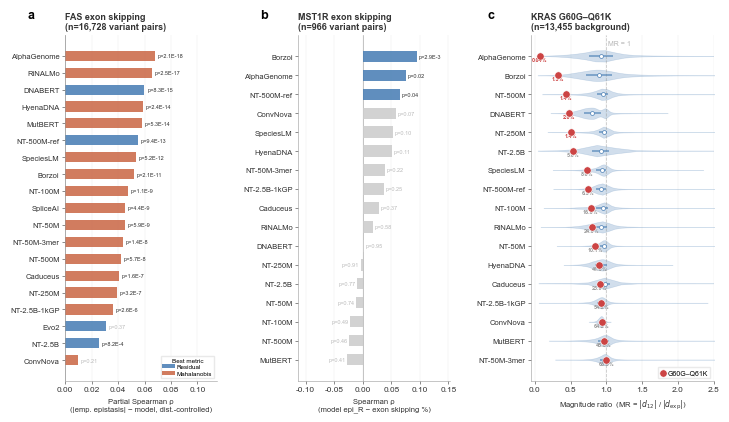

Saved fig_splicing_final to /Users/nicolaslynn/Downloads/output_figs


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE: fig_splicing_final — 3-panel layout
# (a) FAS partial ρ, (b) MST1R ρ, (c) KRAS MR violins
# ═══════════════════════════════════════════════════════════════════════

COL_BLUE   = "#4A7FB5"
COL_TERRA  = "#CB6A49"
COL_NONSIG = "#CCCCCC"
SIG_COLOR  = "#CC4444"
METRIC_COLORS = {"epi_R_singles": COL_BLUE, "global_epi_mahal": COL_TERRA}
METRIC_LABELS = {"epi_R_singles": "Residual", "global_epi_mahal": "Mahalanobis"}

def _format_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ""
    if p >= 0.01:
        return f"{p:.2f}"
    return f"{p:.1e}".replace("e", "E").replace("E-0", "E-").replace("E+0", "E+")

def _at_least_two(arr):
    arr = np.asarray(arr, dtype=float)
    if len(arr) >= 2:
        return arr
    return np.array([0.0, 0.0])

# ── Prepare FAS: best of residual vs Mahalanobis ──
fas_base = fas_summary[fas_summary.metric == "epi_R_singles"].set_index("tool")
fas_alt  = fas_summary[fas_summary.metric == "global_epi_mahal"].set_index("tool")
all_tools_fas = sorted(set(fas_base.index) | set(fas_alt.index))

fas_rows_best = []
for t in all_tools_fas:
    br = fas_base.loc[t, "partial_r"] if t in fas_base.index else np.nan
    bp = fas_base.loc[t, "partial_p"] if t in fas_base.index else np.nan
    ar = fas_alt.loc[t, "partial_r"] if t in fas_alt.index else np.nan
    ap = fas_alt.loc[t, "partial_p"] if t in fas_alt.index else np.nan
    if np.isnan(ar) or (not np.isnan(br) and br >= ar):
        fas_rows_best.append({"tool": t, "best_r": br, "best_p": bp, "metric": "epi_R_singles"})
    else:
        fas_rows_best.append({"tool": t, "best_r": ar, "best_p": ap, "metric": "global_epi_mahal"})

fas_best = pd.DataFrame(fas_rows_best).sort_values("best_r", ascending=False).reset_index(drop=True)
fas_order = fas_best["tool"].tolist()

# ── Prepare MST1R: best of residual vs Mahalanobis ──
mst_rows_best = []
for _, row in mst_summary.iterrows():
    rr, pr = row["r_residual"], row["p_residual"]
    rm, pm = row["r_mahal"], row["p_mahal"]
    if np.isnan(rm) or rr >= rm:
        mst_rows_best.append({"tool": row["tool"], "best_r": rr, "best_p": pr, "metric": "epi_R_singles"})
    else:
        mst_rows_best.append({"tool": row["tool"], "best_r": rm, "best_p": pm, "metric": "global_epi_mahal"})

mst_best = pd.DataFrame(mst_rows_best).sort_values("best_r", ascending=False).reset_index(drop=True)
mst_order = mst_best["tool"].tolist()

# ── Prepare KRAS: sorted by target MR (ascending = best detection first) ──
kras_sorted = kras_stats.sort_values("target_mr", ascending=True).reset_index(drop=True)
kras_order = kras_sorted["tool"].tolist()

# ── Build figure: 3 panels ──
n_fas  = len(fas_order)
n_mst  = len(mst_order)
n_kras = len(kras_order)
n_max  = max(n_fas, n_mst, n_kras)
fig_h_mm = max(90, 4.8 * n_max + 16)

fig = plt.figure(figsize=(183 * mm, fig_h_mm * mm))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2],
                      wspace=0.50, left=0.07, right=0.97, top=0.92, bottom=0.10)
ax_fas  = fig.add_subplot(gs[0])
ax_mst  = fig.add_subplot(gs[1])
ax_viol = fig.add_subplot(gs[2])
for ax in (ax_fas, ax_mst, ax_viol):
    style_ax(ax)

# ═══════════════════════════════════════════════════════════════
# Panel A: FAS — partial Spearman ρ (best metric per model)
# ═══════════════════════════════════════════════════════════════
y_fas = np.arange(n_fas)
fas_vals    = fas_best["best_r"].values
fas_p_vals  = fas_best["best_p"].values
fas_metrics = fas_best["metric"].values
fas_colors  = [METRIC_COLORS[m] for m in fas_metrics]

ax_fas.barh(y_fas, fas_vals, height=0.6, color=fas_colors,
            edgecolor="none", alpha=0.88, zorder=2)
ax_fas.axvline(0, color=GRAY_MID, linewidth=0.4, zorder=1)

x_max = np.nanmax(fas_vals) if np.any(~np.isnan(fas_vals)) else 0.1
for i in range(n_fas):
    p = fas_p_vals[i]
    r = fas_vals[i] if not np.isnan(fas_vals[i]) else 0
    p_str = _format_p(p)
    if p_str:
        col = GRAY_DARK if p < 0.05 else "#BBBBBB"
        ax_fas.text(max(r, 0) + x_max * 0.03, y_fas[i], f"p={p_str}",
                    ha="left", va="center", fontsize=4, color=col)

ax_fas.set_xlabel("Partial Spearman ρ\n(|emp. epistasis| ~ model, dist.-controlled)",
                  fontsize=5.5, color=GRAY_DARK)
ax_fas.set_yticks(y_fas)
ax_fas.set_yticklabels([MODEL_DISPLAY.get(t, t) for t in fas_order], fontsize=5.5)
ax_fas.invert_yaxis()
ax_fas.set_xlim(left=min(0, np.nanmin(fas_vals) - 0.005), right=x_max * 1.7)

legend_patches = [mpatches.Patch(facecolor=METRIC_COLORS[m], alpha=0.88,
                                  edgecolor="none", label=METRIC_LABELS[m])
                  for m in ["epi_R_singles", "global_epi_mahal"]]
ax_fas.legend(handles=legend_patches, loc="lower right", fontsize=4.5, frameon=True,
              fancybox=False, edgecolor=GRAY_LIGHT, facecolor="white", framealpha=0.95,
              handletextpad=0.3, borderpad=0.3, labelspacing=0.2,
              title="Best metric", title_fontsize=4.5)

n_fas_pairs = fas_summary["n"].iloc[0]
ax_fas.set_title(f"FAS exon skipping\n(n={n_fas_pairs:,} variant pairs)", fontsize=6.5,
                 color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

# ═══════════════════════════════════════════════════════════════
# Panel B: MST1R — Spearman ρ (best metric per model)
# ═══════════════════════════════════════════════════════════════
y_mst = np.arange(n_mst)
mst_vals    = mst_best["best_r"].values
mst_p_vals  = mst_best["best_p"].values
mst_metrics = mst_best["metric"].values
mst_colors  = [METRIC_COLORS[m] for m in mst_metrics]
bar_colors_mst = [mst_colors[i] if mst_p_vals[i] < 0.05 else COL_NONSIG for i in range(n_mst)]

ax_mst.barh(y_mst, mst_vals, height=0.6, color=bar_colors_mst,
            edgecolor="none", alpha=0.88, zorder=2)
ax_mst.axvline(0, color=GRAY_MID, linewidth=0.4, zorder=1)

x_max_mst = max(abs(np.nanmin(mst_vals)), abs(np.nanmax(mst_vals)), 0.05)
for i in range(n_mst):
    p = mst_p_vals[i]
    r = mst_vals[i] if not np.isnan(mst_vals[i]) else 0
    p_str = _format_p(p)
    if p_str:
        col = GRAY_DARK if p < 0.05 else "#BBBBBB"
        if r >= 0:
            ax_mst.text(r + x_max_mst * 0.03, y_mst[i], f"p={p_str}",
                        ha="left", va="center", fontsize=4, color=col)
        else:
            ax_mst.text(r - x_max_mst * 0.03, y_mst[i], f"p={p_str}",
                        ha="right", va="center", fontsize=4, color=col)

ax_mst.set_xlabel("Spearman ρ\n(model epi_R ~ exon skipping %)",
                  fontsize=5.5, color=GRAY_DARK)
ax_mst.set_yticks(y_mst)
ax_mst.set_yticklabels([MODEL_DISPLAY.get(t, t) for t in mst_order], fontsize=5.5)
ax_mst.invert_yaxis()
margin = x_max_mst * 0.6
ax_mst.set_xlim(-x_max_mst - margin * 0.3, x_max_mst + margin)

n_mst_pairs = mst_summary["n_resid"].iloc[0]
ax_mst.set_title(f"MST1R exon skipping\n(n={n_mst_pairs:,} variant pairs)", fontsize=6.5,
                 color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

# ═══════════════════════════════════════════════════════════════
# Panel C: KRAS — MR violin plots + target pair dot + percentile
# ═══════════════════════════════════════════════════════════════
y_kras = np.arange(n_kras)
violin_data = [_at_least_two(kras_bg_data.get(t, np.array([0.0]))) for t in kras_order]

# Clip violins to data range so they don't extend below 0
# Use a small negative xlim to give breathing room, then clip bodies after
parts = ax_viol.violinplot(
    violin_data, positions=y_kras, widths=0.6,
    showmeans=False, showmedians=False, showextrema=False, vert=False,
)
for i, pc in enumerate(parts["bodies"]):
    # Clip violin to the actual data range [min, max]
    bg = violin_data[i]
    pc.set_clip_on(True)
    pc.set_facecolor(COL_BLUE)
    pc.set_alpha(0.25)
    pc.set_edgecolor(COL_BLUE)
    pc.set_linewidth(0.4)

# IQR + median
for i, bg in enumerate(violin_data):
    q25, q50, q75 = np.percentile(bg, [25, 50, 75])
    ax_viol.hlines(y_kras[i], q25, q75, color=COL_BLUE, linewidth=1.2, zorder=3, alpha=0.7)
    ax_viol.scatter([q50], [y_kras[i]], color="white", s=8, zorder=4,
                    edgecolors=COL_BLUE, linewidths=0.5)

# Target pair (G60G-Q61K)
target_mrs = kras_sorted["target_mr"].values
ax_viol.scatter(target_mrs, y_kras, color=SIG_COLOR, s=28, zorder=6,
                edgecolors="white", linewidths=0.4, label="G60G–Q61K")

# Percentile annotations to the right of each target dot
for i in range(n_kras):
    pctile = kras_sorted.iloc[i]["p_low"] * 100  # p_low is fraction <= target
    pct_str = f"{pctile:.1f}%" if pctile >= 1 else f"{pctile:.2f}%"
    col = SIG_COLOR if pctile < 5 else GRAY_MID
    ax_viol.text(target_mrs[i], y_kras[i] + 0.32, pct_str,
                 ha="center", va="bottom", fontsize=4, color=col, fontweight="bold")

ax_viol.axvline(1.0, color=GRAY_MID, linewidth=0.6, linestyle="--", alpha=0.5, zorder=1)
ax_viol.text(1.02, -0.7, "MR = 1", fontsize=5, color=GRAY_MID, alpha=0.7, va="center")

ax_viol.set_xlabel(r"Magnitude ratio  (MR = $|d_{12}|$ / $|d_{\mathrm{exp}}|$)",
                   fontsize=5.5, color=GRAY_DARK)
ax_viol.set_yticks(y_kras)
ax_viol.set_yticklabels([MODEL_DISPLAY.get(t, t) for t in kras_order], fontsize=5.5)
ax_viol.invert_yaxis()

# Set xlim with small negative margin so violins aren't clipped at 0
bg_max = np.max([np.percentile(bg, 99) for bg in violin_data])
ax_viol.set_xlim(left=-0.05, right=min(2.5, bg_max * 1.1))

ax_viol.legend(loc="lower right", fontsize=5, frameon=True, fancybox=False,
               edgecolor=GRAY_LIGHT, facecolor="white", framealpha=0.9,
               handlelength=0.8, handletextpad=0.3, borderpad=0.3)

n_kras_bg = int(kras_sorted["n"].iloc[0])
ax_viol.set_title(f"KRAS G60G–Q61K\n(n={n_kras_bg:,} background)", fontsize=6.5,
                  color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

# ── Panel labels ──
for ax, letter in zip([ax_fas, ax_mst, ax_viol], ["a", "b", "c"]):
    ax.text(-0.20, 1.04, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right", color="black")

# ── Save ──
for ext in (".png", ".pdf"):
    fig.savefig(OUT_DIR / f"fig_splicing_final{ext}", dpi=600,
                bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_splicing_final to {OUT_DIR}")

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════

sep = '=' * 70
print(sep)
print('SPLICING FIGURE — STATISTICAL SUMMARY')
print(sep)

# FAS
print(f'\n--- FAS ({fas_summary["n"].iloc[0]:,} pairs) ---')
for metric in ['epi_R_singles', 'global_epi_mahal']:
    sub = fas_summary[fas_summary['metric'] == metric].sort_values('partial_r', ascending=False)
    n_sig = (sub['partial_p'] < 0.05).sum()
    best = sub.iloc[0]
    print(f'  {metric}: {n_sig}/{len(sub)} significant')
    print(f'    Best: {MODEL_DISPLAY.get(best["tool"], best["tool"])} '
          f'(partial ρ={best["partial_r"]:.4f}, p={best["partial_p"]:.2e})')

# MST1R
print(f'\n--- MST1R ({mst_summary["n_resid"].iloc[0]:,} pairs) ---')
print('  Best of epi_R_singles vs global_epi_mahal:')
best_m = mst_best.iloc[0]
n_sig_m = (mst_best['best_p'] < 0.05).sum()
print(f'  {n_sig_m}/{len(mst_best)} significant')
print(f'  Best: {MODEL_DISPLAY.get(best_m["tool"], best_m["tool"])} '
      f'(ρ={best_m["best_r"]:.4f}, p={best_m["best_p"]:.4f}, metric={best_m["metric"]})')

# KRAS
print(f'\n--- KRAS G60G–Q61K ({len(kras_stats)} models) ---')
n_sig_k = (kras_stats['p_low'] < 0.05).sum()
best_k = kras_sorted.iloc[0]
print(f'  Significant (p<0.05): {n_sig_k}/{len(kras_stats)}')
print(f'  Most significant: {MODEL_DISPLAY.get(best_k["tool"], best_k["tool"])} '
      f'(MR={best_k["target_mr"]:.4f}, p={best_k["p_low"]:.2e})')

print(f'\n{sep}')

SPLICING FIGURE — STATISTICAL SUMMARY

--- FAS (16,728 pairs) ---
  epi_R_singles: 15/19 significant
    Best: DNABERT (partial ρ=0.0600, p=8.33e-15)
  global_epi_mahal: 16/19 significant
    Best: AlphaGenome (partial ρ=0.0676, p=2.07e-18)

--- MST1R (966 pairs) ---
  Best of epi_R_singles vs global_epi_mahal:
  3/17 significant
  Best: Borzoi (ρ=0.0956, p=0.0029, metric=epi_R_singles)

--- KRAS G60G–Q61K (17 models) ---
  Significant (p<0.05): 5/17
  Most significant: AlphaGenome (MR=0.0695, p=3.72e-04)



## Supplementary: G60G single-mutation distance from wild type

How "special" does each model see the G60G synonymous mutation? For each model, we extract
the embedding distance from wild type (`len_WT_M1` / `len_WT_M2`) for every single mutation
in the KRAS neighborhood and see where G60G falls in the distribution.

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Compute single-mutation WT distances for KRAS neighborhood
# ═══════════════════════════════════════════════════════════════════════

# Position 25227343 = Q61K (oncogenic missense), position 25227344 = G60G (synonymous, affects splicing)
Q61K = 'KRAS:12:25227343:G:T:N'
G60G = 'KRAS:12:25227344:A:T:N'

g60g_rows = []
g60g_bg_data = {}

for mk, df_all in model_data.items():
    df = df_all[df_all['source'] == 'kras_neighborhood'].copy()
    if len(df) < 10:
        continue

    # Extract single mutations and their WT distances from pairs
    m1_ids = df['epistasis_id'].str.split('|').str[0]
    m2_ids = df['epistasis_id'].str.split('|').str[1]
    singles = pd.concat([
        pd.DataFrame({'mut': m1_ids.values, 'dist_wt': df['len_WT_M1'].values}),
        pd.DataFrame({'mut': m2_ids.values, 'dist_wt': df['len_WT_M2'].values}),
    ]).dropna()
    singles_agg = singles.groupby('mut')['dist_wt'].median()

    if G60G not in singles_agg.index:
        continue

    bg = singles_agg.values
    g60g_dist = singles_agg[G60G]
    q61k_dist = singles_agg.get(Q61K, np.nan)
    pctile = 100.0 * (bg <= g60g_dist).sum() / len(bg)

    g60g_rows.append({
        'tool': mk,
        'g60g_dist': g60g_dist,
        'q61k_dist': q61k_dist,
        'bg_median': float(np.median(bg)),
        'n_muts': len(bg),
        'percentile': pctile,
    })
    g60g_bg_data[mk] = bg

g60g_stats = pd.DataFrame(g60g_rows).sort_values('percentile', ascending=False).reset_index(drop=True)
print(f'{len(g60g_stats)} models with G60G data')
display(g60g_stats[['tool', 'g60g_dist', 'q61k_dist', 'percentile', 'n_muts']])

17 models with G60G data


,tool,g60g_dist,q61k_dist,percentile,n_muts
0,nt500_ref,0.058188,0.032745,93.267108,906
1,nt50_3mer,0.029332,0.019874,79.580574,906
2,dnabert,0.057213,0.042250,75.496689,906
3,nt2500_okgp,0.023795,0.022582,70.860927,906
4,nt250_multi,0.029381,0.072560,69.646799,906
5,alphagenome,0.134149,0.564493,64.459161,906
6,borzoi,0.019408,0.054867,64.017660,906
7,nt50_multi,0.017706,0.016367,51.876380,906
8,rinalmo,0.298908,0.766504,51.655629,906
9,hyenadna,0.000630,0.000843,43.929360,906


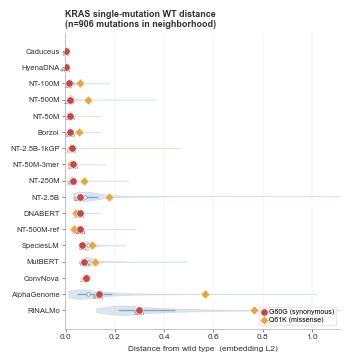

Saved fig_kras_g60g_wt_dist to /Users/nicolaslynn/Downloads/output_figs


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# Plot: G60G single-mutation WT distance — violin + dots
# ═══════════════════════════════════════════════════════════════════════

COL_BLUE   = "#4A7FB5"
SIG_COLOR  = "#CC4444"
Q61K_COLOR = "#E8A838"

def _at_least_two(arr):
    arr = np.asarray(arr, dtype=float)
    return arr if len(arr) >= 2 else np.array([0.0, 0.0])

g60g_sorted = g60g_stats.sort_values('g60g_dist', ascending=True).reset_index(drop=True)
g60g_order = g60g_sorted['tool'].tolist()
n_g = len(g60g_order)

fig_g, ax_g = plt.subplots(figsize=(90 * mm, max(70, 4.8 * n_g + 16) * mm))
style_ax(ax_g)

y_g = np.arange(n_g)
violin_data_g = [_at_least_two(g60g_bg_data.get(t, np.array([0.0]))) for t in g60g_order]

parts = ax_g.violinplot(
    violin_data_g, positions=y_g, widths=0.6,
    showmeans=False, showmedians=False, showextrema=False, vert=False,
)
for pc in parts["bodies"]:
    pc.set_facecolor(COL_BLUE)
    pc.set_alpha(0.20)
    pc.set_edgecolor(COL_BLUE)
    pc.set_linewidth(0.4)

# IQR + median
for i, bg in enumerate(violin_data_g):
    q25, q50, q75 = np.percentile(bg, [25, 50, 75])
    ax_g.hlines(y_g[i], q25, q75, color=COL_BLUE, linewidth=1.0, zorder=3, alpha=0.6)
    ax_g.scatter([q50], [y_g[i]], color="white", s=6, zorder=4,
                 edgecolors=COL_BLUE, linewidths=0.4)

# G60G dots
g60g_dists = g60g_sorted['g60g_dist'].values
ax_g.scatter(g60g_dists, y_g, color=SIG_COLOR, s=28, zorder=6,
             edgecolors="white", linewidths=0.4, label="G60G (synonymous)")

# Q61K dots
q61k_dists = g60g_sorted['q61k_dist'].values
ax_g.scatter(q61k_dists, y_g, color=Q61K_COLOR, s=22, zorder=5, marker='D',
             edgecolors="white", linewidths=0.4, label="Q61K (missense)")

# Percentile annotations
for i in range(n_g):
    pctile = g60g_sorted.iloc[i]['percentile']
    pct_str = f"{pctile:.0f}th" if pctile >= 1 else f"{pctile:.1f}th"
    col = SIG_COLOR if pctile > 90 else GRAY_MID
    ax_g.text(g60g_dists[i], y_g[i] + 0.33, pct_str,
              ha="center", va="bottom", fontsize=4, color=col, fontweight="bold")

ax_g.set_xlabel("Distance from wild type  (embedding L2)", fontsize=6, color=GRAY_DARK)
ax_g.set_yticks(y_g)
ax_g.set_yticklabels([MODEL_DISPLAY.get(t, t) for t in g60g_order], fontsize=5.5)
ax_g.invert_yaxis()

# xlim: don't clip violins on the left
bg_min = min(np.min(bg) for bg in violin_data_g)
bg_max = max(np.percentile(bg, 99) for bg in violin_data_g)
ax_g.set_xlim(left=bg_min - 0.002, right=bg_max * 1.05)

ax_g.legend(loc="lower right", fontsize=5, frameon=True, fancybox=False,
            edgecolor=GRAY_LIGHT, facecolor="white", framealpha=0.9,
            handlelength=0.8, handletextpad=0.3, borderpad=0.3, labelspacing=0.3)

n_muts = int(g60g_sorted['n_muts'].iloc[0])
ax_g.set_title(f"KRAS single-mutation WT distance\n(n={n_muts} mutations in neighborhood)",
               fontsize=6.5, color=GRAY_DARK, pad=4, loc="left", fontweight="bold")

for ext in (".png", ".pdf"):
    fig_g.savefig(OUT_DIR / f"fig_kras_g60g_wt_dist{ext}", dpi=600,
                  bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print(f"Saved fig_kras_g60g_wt_dist to {OUT_DIR}")





In [11]:
g60g_sorted

,tool,g60g_dist,q61k_dist,bg_median,n_muts,percentile
0,caduceus,0.000015,0.000025,0.000025,906,6.732892
1,hyenadna,0.000630,0.000843,0.000650,906,43.929360
2,nt100_multi,0.014099,0.056748,0.021872,906,7.726269
3,nt500_multi,0.016896,0.092492,0.021336,906,25.496689
4,nt50_multi,0.017706,0.016367,0.017553,906,51.876380
5,borzoi,0.019408,0.054867,0.014785,906,64.017660
6,nt2500_okgp,0.023795,0.022582,0.020761,906,70.860927
7,nt50_3mer,0.029332,0.019874,0.019804,906,79.580574
8,nt250_multi,0.029381,0.072560,0.025017,906,69.646799
9,nt2500_multi,0.056873,0.176713,0.080368,906,24.503311
